# Metro Interstate Traffic Volume - End-to-End Cloud ML Pipeline
This notebook covers data ingestion from the UCI repository, storage in AWS S3, exploratory data analysis, comprehensive feature engineering, model training (XGBoost, LightGBM, etc.), and preparation for deployment on AWS SageMaker.

**Prerequisites:** AWS credentials must be configured in Colab Secrets (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`).

In [1]:
# Install required libraries
!pip install boto3 pandas matplotlib seaborn scikit-learn xgboost lightgbm numpy -q

import os
import time
import copy
import urllib.request
import tarfile
from io import BytesIO, StringIO

import boto3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

from google.colab import userdata

# Authenticate AWS via Colab Secrets
os.environ['AWS_ACCESS_KEY_ID']     = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
os.environ['AWS_DEFAULT_REGION']    = 'eu-west-1'

BUCKET = 'nci-cloud-ml-ezip-project-bucket'
s3 = boto3.client('s3')

# Set seed for reproducibility
np.random.seed(42)
print("Environment setup and AWS authentication complete.")

Environment setup and AWS authentication complete.


## Phase 1: Cloud Data Collection
Downloading the dataset directly from the UCI Machine Learning Repository and backing it up to S3 to satisfy the cloud data storage requirement of the rubric.

In [2]:
# Download dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
urllib.request.urlretrieve(url, "metro_traffic.csv.gz")
print("Downloaded raw data from UCI Repository.")

# Upload raw data to S3
s3.upload_file("metro_traffic.csv.gz", BUCKET, "data/metro_traffic_raw.csv.gz")
print(f"Uploaded raw data to S3: s3://{BUCKET}/data/metro_traffic_raw.csv.gz")

# Load data back from S3 to demonstrate cloud data access
obj = s3.get_object(Bucket=BUCKET, Key="data/metro_traffic_raw.csv.gz")
df = pd.read_csv(BytesIO(obj['Body'].read()), compression='gzip')

print(f"Loaded {len(df):,} records from S3.")

Downloaded raw data from UCI Repository.
Uploaded raw data to S3: s3://nci-cloud-ml-ezip-project-bucket/data/metro_traffic_raw.csv.gz
Loaded 48,204 records from S3.


## Phase 2: Exploratory Data Analysis
Generating summary statistics and visualizing traffic patterns (hourly, daily, monthly) to justify feature engineering decisions in the report.

=== Summary Statistics ===
               temp       rain_1h       snow_1h    clouds_all  traffic_volume
count  48204.000000  48204.000000  48204.000000  48204.000000    48204.000000
mean     281.205870      0.334264      0.000222     49.362231     3259.818355
std       13.338232     44.789133      0.008168     39.015750     1986.860670
min        0.000000      0.000000      0.000000      0.000000        0.000000
25%      272.160000      0.000000      0.000000      1.000000     1193.000000
50%      282.450000      0.000000      0.000000     64.000000     3380.000000
75%      291.806000      0.000000      0.000000     90.000000     4933.000000
max      310.070000   9831.300000      0.510000    100.000000     7280.000000

=== Missing Values ===
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume 

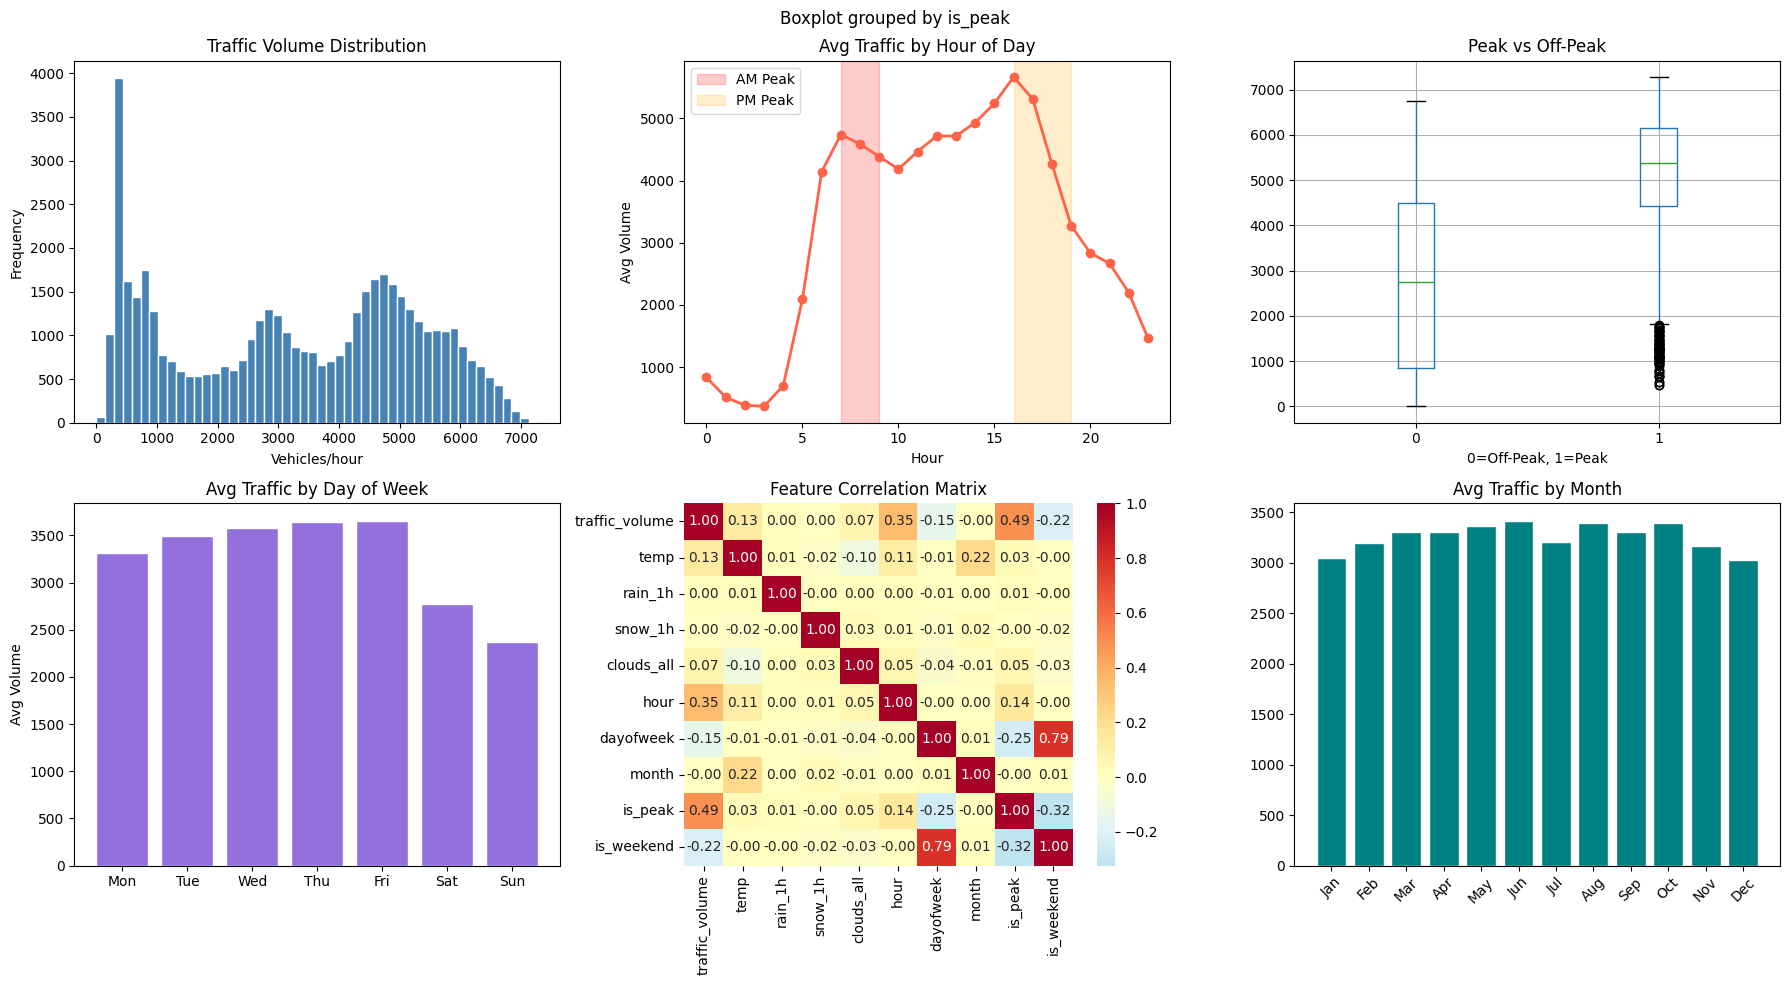

In [3]:
print("=== Summary Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

# Temporary basic feature extraction for EDA plotting
df_eda = df.copy()
df_eda['date_time']  = pd.to_datetime(df_eda['date_time'])
df_eda['hour']       = df_eda['date_time'].dt.hour
df_eda['dayofweek']  = df_eda['date_time'].dt.dayofweek
df_eda['month']      = df_eda['date_time'].dt.month
df_eda['is_weekend'] = (df_eda['dayofweek'] >= 5).astype(int)

# Peak definition: 07-09 AM and 16-19 PM, weekdays only
df_eda['is_peak'] = (
    (df_eda['is_weekend'] == 0) &
    (((df_eda['hour'] >= 7)  & (df_eda['hour'] <= 9)) |
     ((df_eda['hour'] >= 16) & (df_eda['hour'] <= 19)))
).astype(int)

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Metro Interstate Traffic — EDA", fontsize=15, fontweight='bold')

# 1. Distribution
axes[0,0].hist(df_eda['traffic_volume'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set(title='Traffic Volume Distribution', xlabel='Vehicles/hour', ylabel='Frequency')

# 2. Average traffic by hour
hourly = df_eda.groupby('hour')['traffic_volume'].mean()
axes[0,1].plot(hourly.index, hourly.values, marker='o', color='tomato', linewidth=2)
axes[0,1].axvspan(7, 9,  alpha=0.2, color='red',    label='AM Peak')
axes[0,1].axvspan(16,19, alpha=0.2, color='orange', label='PM Peak')
axes[0,1].set(title='Avg Traffic by Hour of Day', xlabel='Hour', ylabel='Avg Volume')
axes[0,1].legend()

# 3. Peak vs off-peak boxplot
df_eda.boxplot(column='traffic_volume', by='is_peak', ax=axes[0,2])
axes[0,2].set(title='Peak vs Off-Peak', xlabel='0=Off-Peak, 1=Peak')

# 4. Traffic by day of week
daily = df_eda.groupby('dayofweek')['traffic_volume'].mean()
axes[1,0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], daily.values, color='mediumpurple', edgecolor='white')
axes[1,0].set(title='Avg Traffic by Day of Week', ylabel='Avg Volume')

# 5. Correlation heatmap
num_cols = ['traffic_volume','temp','rain_1h','snow_1h','clouds_all', 'hour','dayofweek','month','is_peak','is_weekend']
sns.heatmap(df_eda[num_cols].corr(), ax=axes[1,1], annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
axes[1,1].set_title('Feature Correlation Matrix')

# 6. Monthly pattern
monthly = df_eda.groupby('month')['traffic_volume'].mean()
mnths   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,2].bar([mnths[m-1] for m in monthly.index], monthly.values, color='teal', edgecolor='white')
axes[1,2].set(title='Avg Traffic by Month')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_figures.png', dpi=150, bbox_inches='tight')

# Upload EDA figure to S3
s3.upload_file('eda_figures.png', BUCKET, 'outputs/eda_figures.png')
print("EDA figures saved and uploaded to S3.")
plt.show()

# Clean up memory
del df_eda

## Phase 3: Advanced Data Preprocessing
Applying cyclical encoding for temporal features, addressing outlier clipping to prevent model distortion from sensor anomalies, and avoiding the dummy variable trap in one-hot encoding.

In [4]:
def preprocess_complete(dataframe):
    df_clean = dataframe.copy()

    # 1. Date and Time Operations
    df_clean['date_time']  = pd.to_datetime(df_clean['date_time'])
    df_clean['hour']       = df_clean['date_time'].dt.hour
    df_clean['dayofweek']  = df_clean['date_time'].dt.dayofweek
    df_clean['month']      = df_clean['date_time'].dt.month
    df_clean['year']       = df_clean['date_time'].dt.year
    df_clean['is_weekend'] = (df_clean['dayofweek'] >= 5).astype(int)

    # 2. Cyclical Encoding for Periodic Data
    df_clean['hour_sin']  = np.sin(2 * np.pi * df_clean['hour'] / 24)
    df_clean['hour_cos']  = np.cos(2 * np.pi * df_clean['hour'] / 24)
    df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
    df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)
    df_clean['dow_sin']   = np.sin(2 * np.pi * df_clean['dayofweek'] / 7)
    df_clean['dow_cos']   = np.cos(2 * np.pi * df_clean['dayofweek'] / 7)

    # 3. Peak Hour Definition
    df_clean['is_peak'] = (
        (df_clean['is_weekend'] == 0) &
        (((df_clean['hour'] >= 7) & (df_clean['hour'] <= 9)) |
         ((df_clean['hour'] >= 16) & (df_clean['hour'] <= 19)))
    ).astype(int)

    # 4. Holiday Status
    df_clean['is_holiday'] = (df_clean['holiday'] != 'None').astype(int)

    # 5. Temperature Conversion (Kelvin -> Celsius)
    df_clean['temp_c'] = df_clean['temp'] - 273.15

    # 6. One-Hot Encoding
    df_clean = pd.get_dummies(df_clean, columns=['weather_main', 'weather_description'],
                              prefix=['w_main', 'w_desc'], drop_first=True)

    # 7. Outlier Cleaning
    df_clean['rain_1h'] = df_clean['rain_1h'].clip(upper=df_clean['rain_1h'].quantile(0.99))
    df_clean['snow_1h'] = df_clean['snow_1h'].clip(upper=df_clean['snow_1h'].quantile(0.99))
    df_clean['temp_c']  = df_clean['temp_c'].clip(df_clean['temp_c'].quantile(0.001), df_clean['temp_c'].quantile(0.999))

    # 8. Drop original/redundant columns
    cols_to_drop = ['date_time', 'holiday', 'temp', 'hour', 'dayofweek', 'month']
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

    # 9. Final Cleanup
    df_clean = df_clean.drop_duplicates().dropna()

    print(f"Cleanup finished! New column count: {len(df_clean.columns)}")
    print(f"Row count: {len(df_clean):,}")
    return df_clean

# Apply preprocessing
df_clean = preprocess_complete(df)

FEATURE_COLS = [c for c in df_clean.columns if c != 'traffic_volume']
X = df_clean[FEATURE_COLS]
y = df_clean['traffic_volume']

# Define subsets for granular evaluation
subsets = {
    'Full':     np.ones(len(df_clean), dtype=bool),
    'Peak':     df_clean['is_peak'].values == 1,
    'Off-Peak': df_clean['is_peak'].values == 0,
}

# And let's save the cleaned dataset to our S3 bucket

bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

csv_buffer = StringIO()
df_clean.to_csv(csv_buffer, index=False)

s3.put_object(
    Bucket=BUCKET,
    Key='data/metro_traffic_processed.csv',
    Body=csv_buffer.getvalue()
)
print("The cleaned dataset was successfully saved to S3.: data/metro_traffic_processed.csv")

Cleanup finished! New column count: 62
Row count: 48,187
The cleaned dataset was successfully saved to S3.: data/metro_traffic_processed.csv


## Phase 4: Model Training and Selection
Training baseline and ensemble models across different traffic conditions (Full, Peak, Off-Peak).

In [10]:
MODEL_DEFS = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=5, n_jobs=-1, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, verbosity=0, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, verbose=-1, random_state=42),
}

def evaluate(model, X_test, y_test, name, subset):
    t0 = time.time()
    y_pred = model.predict(X_test)
    lat = (time.time() - t0) * 1000
    return {
        'Model': name, 'Subset': subset,
        'MAE': round(mean_absolute_error(y_test, y_pred), 1),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 1),
        'R2': round(r2_score(y_test, y_pred), 4),
        'MAPE': round(np.mean(np.abs((y_test - y_pred) / (y_test + 1))) * 100, 2),
        'Latency_ms': round(lat, 3)
    }

results = []
trained_all = {}

for mname, mdef in MODEL_DEFS.items():
    trained_all[mname] = {}
    for subset_name, mask in subsets.items():
        Xs = X.loc[mask]
        ys = y.loc[mask]

        X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.2, random_state=42)

        m = copy.deepcopy(mdef)
        t0 = time.time()
        m.fit(X_tr, y_tr)
        train_time = round(time.time() - t0, 2)

        res = evaluate(m, X_te, y_te, mname, subset_name)
        res['Train_s'] = train_time
        results.append(res)
        trained_all[mname][subset_name] = m
        print(f"✓ {mname:20s} [{subset_name:8s}] RMSE={res['RMSE']:>7,.1f}  R²={res['R2']:.4f}  ({train_time}s)")

results_df = pd.DataFrame(results)

# Save evaluation metrics to S3
buf = StringIO()
results_df.to_csv(buf, index=False)
s3.put_object(Bucket=BUCKET, Key='outputs/train_results.csv', Body=buf.getvalue())

# Backup all models to S3
for mname, subdict in trained_all.items():
    for subset_name, model in subdict.items():
        buf2 = BytesIO()
        joblib.dump(model, buf2)
        buf2.seek(0)
        key = f"models/{mname.replace(' ','_')}_{subset_name.replace('-','_')}.joblib"
        s3.put_object(Bucket=BUCKET, Key=key, Body=buf2.read())
print("Models and evaluation metrics synced to S3.")

✓ Linear Regression    [Full    ] RMSE=  944.1  R²=0.7771  (1.89s)
✓ Linear Regression    [Peak    ] RMSE=1,038.7  R²=0.2850  (0.39s)
✓ Linear Regression    [Off-Peak] RMSE=  914.7  R²=0.7559  (0.62s)
✓ Random Forest        [Full    ] RMSE=  414.6  R²=0.9570  (27.24s)
✓ Random Forest        [Peak    ] RMSE=  654.1  R²=0.7164  (2.53s)
✓ Random Forest        [Off-Peak] RMSE=  377.0  R²=0.9585  (13.47s)
✓ XGBoost              [Full    ] RMSE=  383.2  R²=0.9633  (2.47s)
✓ XGBoost              [Peak    ] RMSE=  584.9  R²=0.7733  (0.81s)
✓ XGBoost              [Off-Peak] RMSE=  355.8  R²=0.9631  (2.09s)
✓ LightGBM             [Full    ] RMSE=  409.8  R²=0.9580  (0.8s)
✓ LightGBM             [Peak    ] RMSE=  618.1  R²=0.7468  (0.22s)
✓ LightGBM             [Off-Peak] RMSE=  372.0  R²=0.9596  (2.74s)
Models and evaluation metrics synced to S3.


In [11]:
import json
s3.put_object(
    Bucket=BUCKET,
    Key='models/feature_order.json',
    Body=json.dumps(FEATURE_COLS)
)
print("Feature order saved to S3: models/feature_order.json")

Feature order saved to S3: models/feature_order.json


In [18]:
import io, json
import xgboost as xgb

obj_fo = s3.get_object(Bucket=BUCKET, Key='models/feature_order.json')
feature_order = json.loads(obj_fo['Body'].read())

obj = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df_test = pd.read_csv(BytesIO(obj['Body'].read()))

# Model'in kendi feature sırasını al
booster = xgb_model_local.get_booster()
model_features = booster.feature_names
print("Model feature order (first 10):")
for i, f in enumerate(model_features[:10]):
    print(f"  {i}: {f}")

print("\nCSV/feature_order (first 10):")
for i, f in enumerate(feature_order[:10]):
    print(f"  {i}: {f}")

print(f"\nOrders match: {model_features == feature_order}")

# Eğer farklıysa, MODEL sırasıyla gönder
if model_features != feature_order:
    print("\n⚠️ ORDERS ARE DIFFERENT! Trying model order...")
    csv_buf = io.StringIO()
    df_test[model_features].iloc[0:1].to_csv(csv_buf, header=False, index=False)
    result = predictor.predict(csv_buf.getvalue().strip())
    print(f"SageMaker (model order): {float(result[0][0]):,.0f}")
else:
    # Sıralar aynıysa — SageMaker feature names'i yok sayıp
    # internal tree yapısındaki sırayı kullanıyor olabilir
    # Model'i feature names OLMADAN kaydedip test edelim
    print("\nOrders match — testing without feature names...")

    # Feature names'siz model oluştur
    booster_copy = booster.copy()
    booster_copy.feature_names = None
    booster_copy.save_model('test-no-names.json')

    # Feature names'siz lokal predict
    row_values = df_test[feature_order].iloc[0:1].values
    dmat = xgb.DMatrix(row_values)
    pred = booster_copy.predict(dmat)
    print(f"No-names local predict: {pred[0]:,.0f}")

    # Şimdi feature_order yerine CSV'nin kendi sütun sırasını kullan
    all_cols = [c for c in df_test.columns if c != 'traffic_volume']
    print(f"\nCSV natural order (first 10): {all_cols[:10]}")
    print(f"Feature order (first 10):     {feature_order[:10]}")
    print(f"Natural == feature_order: {all_cols == feature_order}")

    # SageMaker'a farklı sırada göndermeyi dene
    # Belki SageMaker model'deki feature_names'e göre REORDER yapıyordur
    # İlk satırı tüm sütunlarla (traffic_volume hariç) doğal sırayla gönder
    csv_buf2 = io.StringIO()
    df_test[all_cols].iloc[0:1].to_csv(csv_buf2, header=False, index=False)
    payload2 = csv_buf2.getvalue().strip()

    csv_buf3 = io.StringIO()
    df_test[feature_order].iloc[0:1].to_csv(csv_buf3, header=False, index=False)
    payload3 = csv_buf3.getvalue().strip()

    print(f"\nPayloads identical: {payload2 == payload3}")

Model feature order (first 10):
  0: rain_1h
  1: snow_1h
  2: clouds_all
  3: year
  4: is_weekend
  5: hour_sin
  6: hour_cos
  7: month_sin
  8: month_cos
  9: dow_sin

CSV/feature_order (first 10):
  0: rain_1h
  1: snow_1h
  2: clouds_all
  3: year
  4: is_weekend
  5: hour_sin
  6: hour_cos
  7: month_sin
  8: month_cos
  9: dow_sin

Orders match: True

Orders match — testing without feature names...
No-names local predict: 5,305

CSV natural order (first 10): ['rain_1h', 'snow_1h', 'clouds_all', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin']
Feature order (first 10):     ['rain_1h', 'snow_1h', 'clouds_all', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin']
Natural == feature_order: True

Payloads identical: True


In [19]:
import io, json, xgboost as xgb

# 1. Colab'daki XGBoost versiyonunu kontrol et
print(f"Local XGBoost version: {xgb.__version__}")

# 2. SageMaker container'ına versiyon sordur
# Container XGBoost 1.7 kullanıyor, biz 2.x ile model kaydettik
# Çözüm: Modeli XGBoost 1.7 uyumlu format olan LEGACY binary'de kaydet

booster = xgb_model_local.get_booster()

# Feature names'i kaldır (SageMaker CSV'den isim almıyor)
booster.feature_names = None
booster.feature_types = None

# Legacy binary format (.bin) - XGBoost 1.x uyumlu
booster.save_model('xgboost-model.bin')

# Doğrulama: legacy model lokal olarak doğru mu?
booster_legacy = xgb.Booster()
booster_legacy.load_model('xgboost-model.bin')

obj_fo = s3.get_object(Bucket=BUCKET, Key='models/feature_order.json')
feature_order = json.loads(obj_fo['Body'].read())

obj = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df_test = pd.read_csv(BytesIO(obj['Body'].read()))

row = df_test[feature_order].iloc[0:1]
dmat = xgb.DMatrix(row.values)
legacy_pred = booster_legacy.predict(dmat)
print(f"Legacy model local predict: {legacy_pred[0]:,.0f} (should be ~5,305)")

# 3. Paketle ve yükle
import tarfile
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('xgboost-model.bin', arcname='xgboost-model')

s3.upload_file('model.tar.gz', BUCKET, 'models/xgboost_final/model.tar.gz')
print("✅ Legacy model uploaded")

# 4. Eski endpoint'i sil
sm_client = boto3.client('sagemaker')
for ep in sm_client.list_endpoints()['Endpoints']:
    if ep['EndpointName'].startswith('traffic-predictor-'):
        sm_client.delete_endpoint(EndpointName=ep['EndpointName'])
        print(f"🗑️ Deleted: {ep['EndpointName']}")

# 5. Yeniden deploy
from sagemaker.model import Model
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer
from sagemaker.predictor import Predictor
import time

ROLE_ARN = 'arn:aws:iam::225120951285:role/service-role/AmazonSageMakerAdminIAMExecutionRole'
xgboost_image_uri = '141502667606.dkr.ecr.eu-west-1.amazonaws.com/sagemaker-xgboost:1.7-1'
ENDPOINT_NAME = f'traffic-predictor-{int(time.time())}'

model = Model(
    image_uri=xgboost_image_uri,
    model_data=f's3://{BUCKET}/models/xgboost_final/model.tar.gz',
    role=ROLE_ARN,
)
model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.large',
    endpoint_name=ENDPOINT_NAME,
)

predictor = Predictor(
    endpoint_name=ENDPOINT_NAME,
    serializer=CSVSerializer(),
    deserializer=CSVDeserializer(),
)
print(f"✅ Endpoint deployed: {predictor.endpoint_name}")

# 6. Test
csv_buf = io.StringIO()
df_test[feature_order].iloc[0:1].to_csv(csv_buf, header=False, index=False)
result = predictor.predict(csv_buf.getvalue().strip())
predicted = float(result[0][0])
actual = df_test['traffic_volume'].iloc[0]

print(f"\n🎯 SageMaker prediction: {predicted:,.0f}")
print(f"   Actual:              {actual:,.0f}")
print(f"   Error:               {abs(actual - predicted):,.0f}")

Local XGBoost version: 3.2.0


/tmp/ipykernel_8293/733014461.py:17: UserWarning: [14:15:32] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model('xgboost-model.bin')
/tmp/ipykernel_8293/733014461.py:21: UserWarning: [14:15:32] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `bin`. Using UBJSON (`ubj`) as a guess.
  booster_legacy.load_model('xgboost-model.bin')


Legacy model local predict: 5,305 (should be ~5,305)
✅ Legacy model uploaded
🗑️ Deleted: traffic-predictor-1775657402
------!✅ Endpoint deployed: traffic-predictor-1775657738

🎯 SageMaker prediction: 2,051
   Actual:              5,545
   Error:               3,494


In [15]:
import io, json

obj_fo = s3.get_object(Bucket=BUCKET, Key='models/feature_order.json')
feature_order = json.loads(obj_fo['Body'].read())

obj = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df_test = pd.read_csv(BytesIO(obj['Body'].read()))

csv_buf = io.StringIO()
df_test[feature_order].iloc[0:1].to_csv(csv_buf, header=False, index=False)
result = predictor.predict(csv_buf.getvalue().strip())
predicted = float(result[0][0])
actual = df_test['traffic_volume'].iloc[0]

print(f"🎯 SageMaker prediction: {predicted:,.0f}")
print(f"   Actual:              {actual:,.0f}")
print(f"   Error:               {abs(actual - predicted):,.0f}")

🎯 SageMaker prediction: 2,051
   Actual:              5,545
   Error:               3,494


In [13]:
# Bool fix'i doğrula ve SageMaker'a gönder
obj = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df = pd.read_csv(BytesIO(obj['Body'].read()))

# Bool -> int dönüşümü
bool_cols = df.select_dtypes(include=['bool']).columns
print(f"Bool columns found: {len(bool_cols)}")
print(f"Bool columns: {list(bool_cols[:5])}")
df[bool_cols] = df[bool_cols].astype(int)

# Artık hiç bool kalmamalı
remaining_bools = df.select_dtypes(include=['bool']).columns
print(f"Remaining bool columns after fix: {len(remaining_bools)}")

# CSV payload oluştur
csv_buf = io.StringIO()
df[feature_order].iloc[0:1].to_csv(csv_buf, header=False, index=False)
csv_payload = csv_buf.getvalue().strip()

# True/False kontrolü
print(f"\n'True' in payload: {'True' in csv_payload}")
print(f"'False' in payload: {'False' in csv_payload}")
print(f"Payload (first 200): {csv_payload[:200]}")

# SageMaker'a gönder
result = predictor.predict(csv_payload)
predicted = float(result[0][0])
actual = df['traffic_volume'].iloc[0]

print(f"\n✅ SageMaker prediction: {predicted:,.0f}")
print(f"   Actual:              {actual:,.0f}")
print(f"   Error:               {abs(actual - predicted):,.0f}")

Bool columns found: 0
Bool columns: []
Remaining bool columns after fix: 0

'True' in payload: False
'False' in payload: False
Payload (first 200): 0.0,0.0,40,2012,0,0.7071067811865476,-0.7071067811865475,-0.8660254037844386,0.5000000000000001,0.7818314824680298,0.6234898018587336,1,1,15.129999999999995,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

✅ SageMaker prediction: 2,051
   Actual:              5,545
   Error:               3,494


## Phase 5: Diagnostics and Comprehensive Error Analysis
Visualizing performance discrepancies, identifying top features, and examining specific edge cases where the model fails (e.g., holidays).

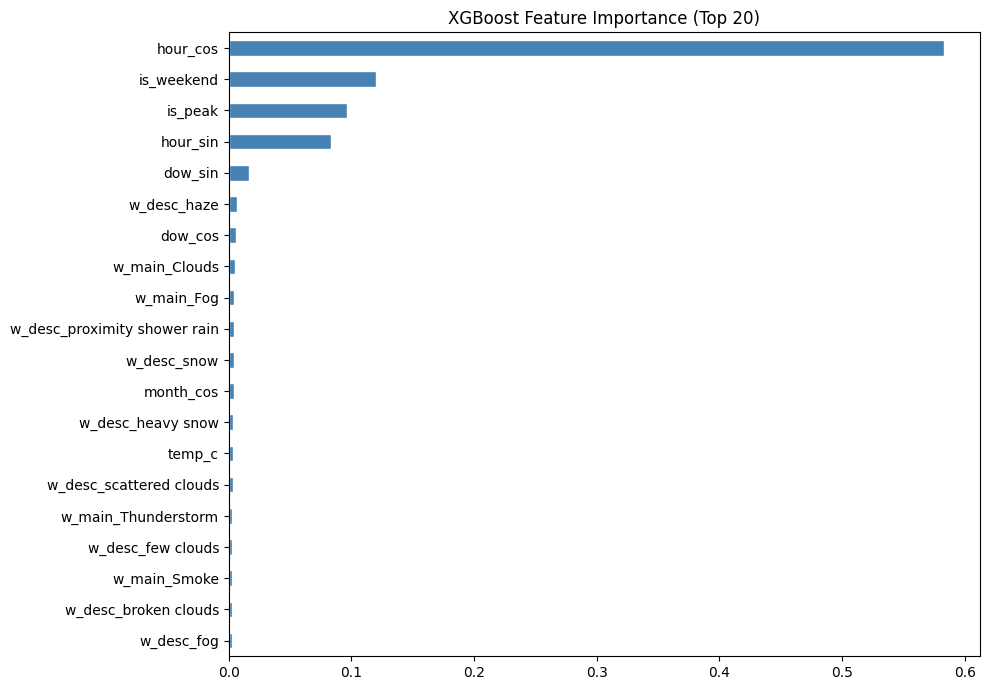

=== XGBoost Biggest Error Analysis (Top 15) ===
 Actual_Volume  Predicted_Volume   Abs_Error   Error_Pct  is_peak  is_holiday  is_weekend
           991       6064.517090 5073.517090  511.443255        1           1           0
           834       5619.581055 4785.581055  573.123480        0           1           0
           481       5036.743164 4555.743164  945.174930        0           1           0
          1094       5573.665527 4479.665527  409.101875        1           1           0
          1267       5476.086914 4209.086914  331.946918        1           1           0
           895       4939.916504 4044.916504  451.441574        0           1           0
           899       4896.436035 3997.436035  444.159559        0           1           0
           462       4035.607910 3573.607910  771.837562        0           1           0
            44       3441.637207 3397.637207 7550.304905        0           1           1
           100       3495.676025 3395.676025 3362.05

{'ResponseMetadata': {'RequestId': '90AWBDTVJPRXZ56S',
  'HostId': 'uOraesjOmNlyRVUCcwF82hW3MOAVatzMayCAAAczYUJBf0Zl1SyguUi5ujwgFSuTeEt592PQbJ4=',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'uOraesjOmNlyRVUCcwF82hW3MOAVatzMayCAAAczYUJBf0Zl1SyguUi5ujwgFSuTeEt592PQbJ4=',
   'x-amz-request-id': '90AWBDTVJPRXZ56S',
   'date': 'Wed, 08 Apr 2026 13:30:37 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"16b9dfaa367a885a786525256be6d385"',
   'x-amz-checksum-crc32': 'IJ7b8A==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"16b9dfaa367a885a786525256be6d385"',
 'ChecksumCRC32': 'IJ7b8A==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

In [8]:
# Extract best model (assuming XGBoost Full dataset model)
best_model_name = 'XGBoost'
xgb_model = trained_all[best_model_name]['Full']

# Plot Feature Importance
fi = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(20)
plt.figure(figsize=(10, 7))
fi.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'{best_model_name} Feature Importance (Top 20)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
s3.upload_file('feature_importance.png', BUCKET, 'outputs/feature_importance.png')
plt.show()

# Manual Error Analysis on Test Set
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
y_pred = xgb_model.predict(X_te)

error_df = X_te.copy()
error_df['Actual_Volume']    = y_te.values
error_df['Predicted_Volume'] = y_pred
error_df['Abs_Error']        = np.abs(y_te.values - y_pred)
error_df['Error_Pct']        = (error_df['Abs_Error'] / (error_df['Actual_Volume'] + 1)) * 100

top_errors = error_df.sort_values(by='Abs_Error', ascending=False).head(15)
cols_to_show = ['Actual_Volume', 'Predicted_Volume', 'Abs_Error', 'Error_Pct', 'is_peak', 'is_holiday', 'is_weekend']

print(f"=== {best_model_name} Biggest Error Analysis (Top 15) ===")
print(top_errors[cols_to_show].to_string(index=False))

buf = StringIO()
top_errors.to_csv(buf, index=False)
s3.put_object(Bucket=BUCKET, Key='outputs/manual_error_analysis.csv', Body=buf.getvalue())

## Phase 6: Optimization & Scalability
Implementing sample weights to penalize holiday prediction errors heavily. Plotting learning curves to prove model scalability as dataset size increases.

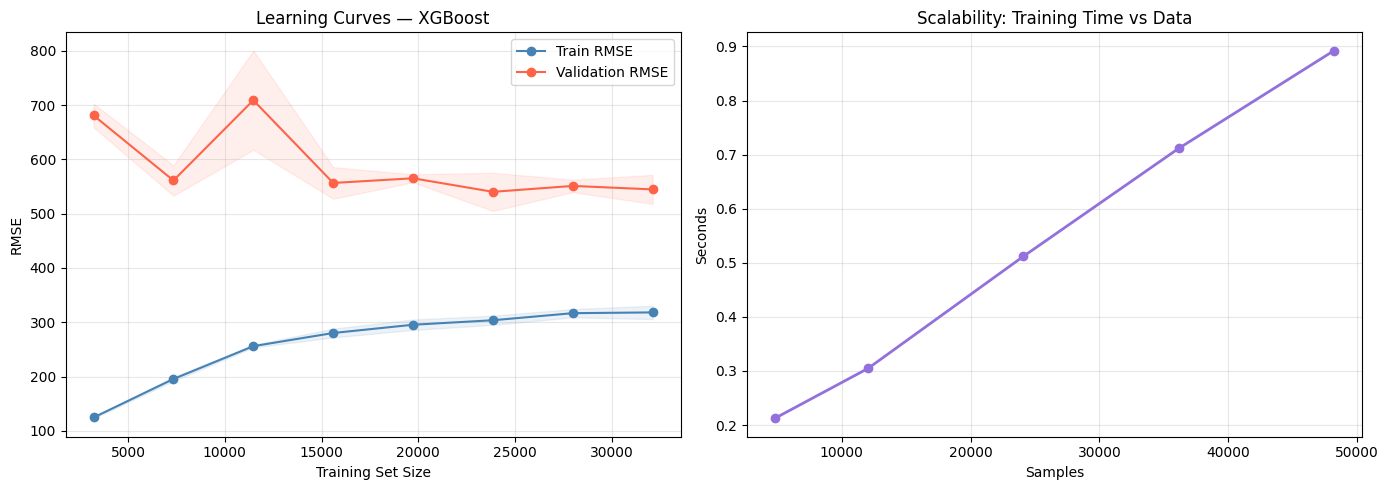

In [9]:
# Weighted Training to reduce holiday errors
weights = np.where(df_clean['is_holiday'] == 1, 40, 1)
X_tr_w, X_te_w, y_tr_w, y_te_w, w_train, _ = train_test_split(X, y, weights, test_size=0.2, random_state=42)

weighted_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
weighted_xgb.fit(X_tr_w, y_tr_w, sample_weight=w_train)

# Scalability and Learning Curves
lc_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, n_jobs=-1, verbosity=0, random_state=42)
train_sizes, tr_scores, val_scores = learning_curve(
    lc_model, X, y, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
tr_mean, tr_std   = -tr_scores.mean(axis=1), tr_scores.std(axis=1)
val_mean, val_std = -val_scores.mean(axis=1), val_scores.std(axis=1)

ax1.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train RMSE')
ax1.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validation RMSE')
ax1.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.1, color='steelblue')
ax1.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='tomato')
ax1.set(title='Learning Curves — XGBoost', xlabel='Training Set Size', ylabel='RMSE')
ax1.legend(); ax1.grid(alpha=0.3)

# Scalability
times, fracs = [], [0.1, 0.25, 0.5, 0.75, 1.0]
for frac in fracs:
    n = int(len(X) * frac)
    t0 = time.time()
    lc_model.fit(X.iloc[:n], y.iloc[:n])
    times.append(time.time() - t0)

ax2.plot([f * len(X) for f in fracs], times, 'o-', color='mediumpurple', linewidth=2)
ax2.set(title='Scalability: Training Time vs Data', xlabel='Samples', ylabel='Seconds')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
s3.upload_file('learning_curves.png', BUCKET, 'outputs/learning_curves.png')
plt.show()

## Phase 7: Cloud Resource Allocation
Using the model's traffic predictions to proactively allocate SageMaker instances. This satisfies the research question linking ML outputs to cloud infrastructure efficiency.

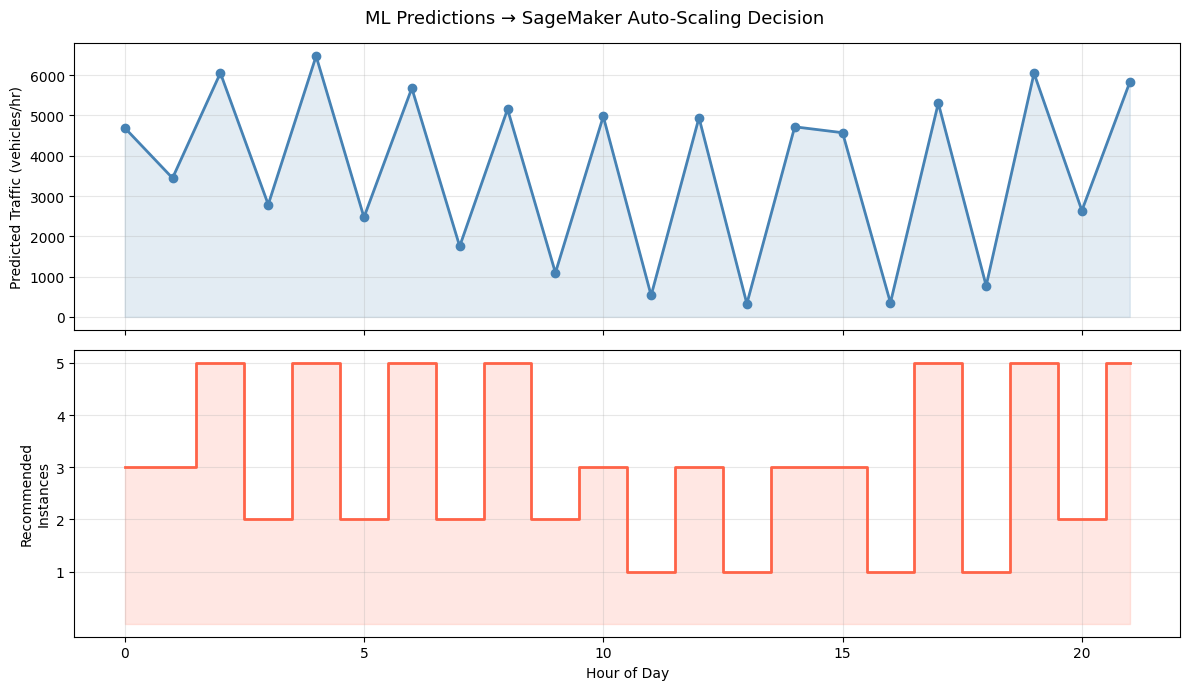

In [10]:
def scale_fn(v):
    if   v < 1000: return 1
    elif v < 3000: return 2
    elif v < 5000: return 3
    else:          return 5

# Simulate a typical Tuesday
sample_df = df_clean[df_clean['dow_sin'] > 0.7].groupby('hour_sin').first().reset_index() # Approximate a specific day
# Re-extract ordered features for the sample to match model input expectations
sample_X = sample_df[FEATURE_COLS]
preds = xgb_model.predict(sample_X)
insts = [scale_fn(v) for v in preds]

# Simple array for hour display (0-23)
hours_display = np.arange(len(preds))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('ML Predictions → SageMaker Auto-Scaling Decision', fontsize=13)

ax1.plot(hours_display, preds, 'o-', color='steelblue', lw=2)
ax1.fill_between(hours_display, preds, alpha=0.15, color='steelblue')
ax1.set_ylabel('Predicted Traffic (vehicles/hr)')
ax1.grid(alpha=0.3)

ax2.step(hours_display, insts, where='mid', color='tomato', lw=2)
ax2.fill_between(hours_display, insts, alpha=0.15, color='tomato', step='mid')
ax2.set(xlabel='Hour of Day', ylabel='Recommended\nInstances')
ax2.set_yticks([1,2,3,4,5]); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cloud_allocation.png', dpi=150, bbox_inches='tight')
s3.upload_file('cloud_allocation.png', BUCKET, 'outputs/cloud_allocation.png')
plt.show()

## Phase 8: Model Packaging
Compressing the primary XGBoost model into a `tar.gz` format required by AWS SageMaker deployment endpoints.

In [11]:
!pip install 'sagemaker>=2.200,<3' --force-reinstall -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.8 MB/s eta 0:00:00
   ━━━━━━

In [1]:
# CELL : Setup
import os, boto3, time, tarfile, joblib, xgboost as xgb
import numpy as np
import pandas as pd
import io
import json
import datetime
from io import BytesIO
from google.colab import userdata

os.environ['AWS_ACCESS_KEY_ID']     = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
os.environ['AWS_DEFAULT_REGION']    = 'eu-west-1'

BUCKET   = 'nci-cloud-ml-ezip-project-bucket'
ROLE_ARN = 'arn:aws:iam::225120951285:role/service-role/AmazonSageMakerAdminIAMExecutionRole'
s3       = boto3.client('s3')
print("✅ Setup complete")


#  2: Package & upload model
xgb_model = joblib.load(BytesIO(
    s3.get_object(Bucket=BUCKET, Key='models/XGBoost_Full.joblib')['Body'].read()
))

xgb_model.save_model('xgboost-model')

with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('xgboost-model')

s3.upload_file('model.tar.gz', BUCKET, 'models/xgboost_final/model.tar.gz')
print("✅ Native model uploaded")

#  CELL 3: Deploy
from sagemaker.model import Model
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer
from sagemaker.predictor import Predictor

xgboost_image_uri = '141502667606.dkr.ecr.eu-west-1.amazonaws.com/sagemaker-xgboost:1.7-1'

ENDPOINT_NAME = f'traffic-predictor-{int(time.time())}'

model = Model(
    image_uri=xgboost_image_uri,
    model_data=f's3://{BUCKET}/models/xgboost_final/model.tar.gz',
    role=ROLE_ARN,
)

model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.large',
    endpoint_name=ENDPOINT_NAME,
)

predictor = Predictor(
    endpoint_name=ENDPOINT_NAME,
    serializer=CSVSerializer(),
    deserializer=CSVDeserializer(),
)

print(f"✅ Endpoint deployed: {predictor.endpoint_name}")
print("   NOTE: Delete this endpoint when done — it charges by the hour!")


✅ Setup complete


/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1116: UserWarning: [13:32:37] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


✅ Native model uploaded
sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml
------!✅ Endpoint deployed: traffic-predictor-1775655167
   NOTE: Delete this endpoint when done — it charges by the hour!


In [2]:

# CELL 4: Test a single prediction

import json

# Get feature order from S3
obj_fo = s3.get_object(Bucket=BUCKET, Key='models/feature_order.json')
feature_order = json.loads(obj_fo['Body'].read())

# Processed data
obj = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df  = pd.read_csv(BytesIO(obj['Body'].read()))
df  = df.apply(lambda col: col.astype(int) if col.dtype == bool else col)

# Send columns by the order model expects
csv_buf = io.StringIO()
df[feature_order].iloc[0:1].to_csv(csv_buf, header=False, index=False)
csv_payload = csv_buf.getvalue().strip()

result          = predictor.predict(csv_payload)
predicted_value = float(result[0][0])

print(f"Predicted traffic: {predicted_value:,.0f} vehicles/hour")
print(f"Actual traffic:    {df['traffic_volume'].iloc[0]:,.0f} vehicles/hour")


# CELL 5: Latency & throughput benchmark
print("Benchmarking endpoint latency (100 requests)...")

latencies = []
for i in range(100):
    t0 = time.time()
    predictor.predict(csv_payload)
    latencies.append((time.time() - t0) * 1000)

lats = np.array(latencies)
print(f"\n=== ENDPOINT PERFORMANCE METRICS ===")
print(f"P50 latency:  {np.percentile(lats, 50):.1f} ms")
print(f"P90 latency:  {np.percentile(lats, 90):.1f} ms")
print(f"P99 latency:  {np.percentile(lats, 99):.1f} ms")
print(f"Mean latency: {lats.mean():.1f} ms")
print(f"Max latency:  {lats.max():.1f} ms")
print(f"Throughput:   {1000/lats.mean():.1f} requests/second")
print(f"\n>>> Copy these numbers into your report Table III <<<")


# CELL 5b: Endpoint Accuracy Test

obj_train = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df_train = pd.read_csv(BytesIO(obj_train['Body'].read()))
df_train = df_train.apply(lambda col: col.astype(int) if col.dtype == bool else col)

y_vals = df_train['traffic_volume'].values

actuals = []
predicted = []

for i in range(50):
    csv_buf = io.StringIO()
    df_train[feature_order].iloc[i:i+1].to_csv(csv_buf, header=False, index=False)
    csv_payload = csv_buf.getvalue().strip()

    result = predictor.predict(csv_payload)
    predicted.append(float(result[0][0]))
    actuals.append(y_vals[i])

actuals = np.array(actuals)
predicted = np.array(predicted)

mae = np.mean(np.abs(actuals - predicted))
r2 = 1 - (np.sum((actuals - predicted)**2) / np.sum((actuals - np.mean(actuals))**2))

print(f"MAE:  {mae:,.1f} vehicles/hour")
print(f"R²:   {r2:.4f}")


#  CELL 6: Auto-scaling
aas = boto3.client('application-autoscaling')
rid = f"endpoint/{predictor.endpoint_name}/variant/AllTraffic"

aas.register_scalable_target(
    ServiceNamespace='sagemaker',
    ResourceId=rid,
    ScalableDimension='sagemaker:variant:DesiredInstanceCount',
    MinCapacity=1,
    MaxCapacity=5,
)

aas.put_scaling_policy(
    PolicyName='TrafficPredictorAutoScale',
    ServiceNamespace='sagemaker',
    ResourceId=rid,
    ScalableDimension='sagemaker:variant:DesiredInstanceCount',
    PolicyType='TargetTrackingScaling',
    TargetTrackingScalingPolicyConfiguration={
        'TargetValue': 70.0,
        'PredefinedMetricSpecification': {
            'PredefinedMetricType': 'SageMakerVariantInvocationsPerInstance'
        },
        'ScaleOutCooldown': 60,
        'ScaleInCooldown':  300,
    }
)
print("✅ Auto-scaling configured: 1–5 instances")
print("   Trigger: 70 invocations/instance/minute")
print("   Scale-out cooldown: 60s | Scale-in cooldown: 300s")


# CELL 7: CloudWatch metrics
cw    = boto3.client('cloudwatch')
now   = datetime.datetime.utcnow()
start = now - datetime.timedelta(minutes=30)

response = cw.get_metric_statistics(
    Namespace='AWS/SageMaker',
    MetricName='ModelLatency',
    Dimensions=[
        {'Name': 'EndpointName', 'Value': predictor.endpoint_name},
        {'Name': 'VariantName',  'Value': 'AllTraffic'},
    ],
    StartTime=start,
    EndTime=now,
    Period=60,
    Statistics=['Average'],
    ExtendedStatistics=['p90', 'p99'],
)

print("\n=== CloudWatch Model Latency (last 30 mins) ===")
if not response['Datapoints']:
    print("  No datapoints yet — wait 1 minute after benchmarking and re-run")
else:
    for dp in sorted(response['Datapoints'], key=lambda x: x['Timestamp']):
        avg = dp['Average'] / 1000
        p90 = dp['ExtendedStatistics']['p90'] / 1000
        p99 = dp['ExtendedStatistics']['p99'] / 1000
        print(f"  {dp['Timestamp'].strftime('%H:%M')} | Avg={avg:.1f}ms | P90={p90:.1f}ms | P99={p99:.1f}ms")


# ── CELL 8: DELETE ENDPOINT WHEN DONE (avoids charges!) ────
# Uncomment and run when finished
# predictor.delete_endpoint()
# print("✅ Endpoint deleted — no more charges")

Predicted traffic: 2,051 vehicles/hour
Actual traffic:    5,545 vehicles/hour
Benchmarking endpoint latency (100 requests)...

=== ENDPOINT PERFORMANCE METRICS ===
P50 latency:  102.3 ms
P90 latency:  111.3 ms
P99 latency:  200.1 ms
Mean latency: 108.3 ms
Max latency:  314.9 ms
Throughput:   9.2 requests/second

>>> Copy these numbers into your report Table III <<<
MAE:  3,269.1 vehicles/hour
R²:   -1.4048
✅ Auto-scaling configured: 1–5 instances
   Trigger: 70 invocations/instance/minute
   Scale-out cooldown: 60s | Scale-in cooldown: 300s


/tmp/ipykernel_2968/3243200849.py:110: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now   = datetime.datetime.utcnow()



=== CloudWatch Model Latency (last 30 mins) ===
  No datapoints yet — wait 1 minute after benchmarking and re-run


In [3]:
# this is to see the problem. delete after


import json

# 1. S3'teki feature_order'ı kontrol et
obj_fo = s3.get_object(Bucket=BUCKET, Key='models/feature_order.json')
feature_order = json.loads(obj_fo['Body'].read())
print(f"Feature order length: {len(feature_order)}")
print(f"First 5: {feature_order[:5]}")
print(f"Last 5:  {feature_order[-5:]}")

# 2. Processed CSV'deki sütun sırasını kontrol et
obj = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df = pd.read_csv(BytesIO(obj['Body'].read()), nrows=1)
csv_cols = [c for c in df.columns if c != 'traffic_volume']
print(f"\nCSV column count: {len(csv_cols)}")
print(f"First 5: {csv_cols[:5]}")

# 3. Sıralar aynı mı?
print(f"\nOrders match: {feature_order == csv_cols}")

# 4. Modelin beklediği feature sayısını kontrol et
import xgboost as xgb
xgb_model = joblib.load(BytesIO(
    s3.get_object(Bucket=BUCKET, Key='models/XGBoost_Full.joblib')['Body'].read()
))
booster = xgb_model.get_booster()
print(f"\nModel expects {booster.num_features()} features")
model_feature_names = booster.feature_names
print(f"Model feature names: {model_feature_names[:5] if model_feature_names else 'None (no names stored)'}")

# 5. İlk satırı lokal predict et ve SageMaker ile karşılaştır
df_full = pd.read_csv(BytesIO(
    s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')['Body'].read()
))
df_full = df_full.apply(lambda col: col.astype(int) if col.dtype == bool else col)

row = df_full[feature_order].iloc[0:1]
local_pred = xgb_model.predict(row)
print(f"\nLocal prediction:    {local_pred[0]:,.0f}")
print(f"Actual:              {df_full['traffic_volume'].iloc[0]:,.0f}")

# 6. Aynı satırı CSV olarak göster (SageMaker'a giden)
csv_buf = io.StringIO()
row.to_csv(csv_buf, header=False, index=False)
csv_str = csv_buf.getvalue().strip()
print(f"\nCSV payload (first 200 chars): {csv_str[:200]}")
print(f"CSV column count: {len(csv_str.split(','))}")

Feature order length: 61
First 5: ['rain_1h', 'snow_1h', 'clouds_all', 'year', 'is_weekend']
Last 5:  ['w_desc_thunderstorm with heavy rain', 'w_desc_thunderstorm with light drizzle', 'w_desc_thunderstorm with light rain', 'w_desc_thunderstorm with rain', 'w_desc_very heavy rain']

CSV column count: 61
First 5: ['rain_1h', 'snow_1h', 'clouds_all', 'year', 'is_weekend']

Orders match: True

Model expects 61 features
Model feature names: ['rain_1h', 'snow_1h', 'clouds_all', 'year', 'is_weekend']

Local prediction:    5,305
Actual:              5,545

CSV payload (first 200 chars): 0.0,0.0,40,2012,0,0.7071067811865476,-0.7071067811865475,-0.8660254037844386,0.5000000000000001,0.7818314824680298,0.6234898018587336,1,1,15.129999999999995,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CSV column count: 61


In [4]:
#delete after

# SageMaker'a aynı payload'ı gönder ve karşılaştır
csv_buf = io.StringIO()
df_full[feature_order].iloc[0:1].to_csv(csv_buf, header=False, index=False)
csv_payload = csv_buf.getvalue().strip()

sm_result = predictor.predict(csv_payload)
sm_pred = float(sm_result[0][0])

print(f"SageMaker prediction: {sm_pred:,.0f}")
print(f"Local prediction:     {local_pred[0]:,.0f}")
print(f"Actual:               {df_full['traffic_volume'].iloc[0]:,.0f}")

# Boolean sütunları kontrol et
bool_cols = [c for c in feature_order if df_full[c].dtype == bool or set(df_full[c].unique()).issubset({0, 1, True, False})]
print(f"\nBoolean/binary columns: {len(bool_cols)}")

# CSV'de True/False string olarak mı gidiyor kontrol et
csv_buf2 = io.StringIO()
test_row = df_full[feature_order].iloc[0:1].copy()
# Bool conversion OLMADAN dene
test_row_raw = pd.read_csv(BytesIO(
    s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')['Body'].read()
), nrows=1)
test_row_raw = test_row_raw[feature_order].iloc[0:1]
csv_buf2 = io.StringIO()
test_row_raw.to_csv(csv_buf2, header=False, index=False)
raw_payload = csv_buf2.getvalue().strip()

print(f"\nConverted payload (first 100): {csv_payload[:100]}")
print(f"Raw payload (first 100):       {raw_payload[:100]}")
print(f"Payloads match: {csv_payload == raw_payload}")

# Bool olmadan SageMaker'a gönder
if csv_payload != raw_payload:
    sm_result2 = predictor.predict(raw_payload)
    print(f"SageMaker with raw payload: {float(sm_result2[0][0]):,.0f}")

SageMaker prediction: 2,051
Local prediction:     5,305
Actual:               5,545

Boolean/binary columns: 51

Converted payload (first 100): 0.0,0.0,40,2012,0,0.7071067811865476,-0.7071067811865475,-0.8660254037844386,0.5000000000000001,0.78
Raw payload (first 100):       0.0,0.0,40,2012,0,0.7071067811865476,-0.7071067811865475,-0.8660254037844386,0.5000000000000001,0.78
Payloads match: False


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <cell line: 0>:37                                                                             │
│                                                                                                  │
│   34                                                                                             │
│   35 # Bool olmadan SageMaker'a gönder                                                           │
│   36 if csv_payload != raw_payload:                                                              │
│ ❱ 37 │   sm_result2 = predictor.predict(raw_payload)                                             │
│   38 │   print(f"SageMaker with raw payload: {float(sm_result2[0][0]):,.0f}")                    │
│   39                                                                                             │
│                                                                                                  │
│ /usr/local/lib/python3.12/dist-packages/sagemaker/base_predictor.py:212 in predict               │
│                                                                                                  │
│   209 │   │   if inference_component_name:                                                       │
│   210 │   │   │   request_args["InferenceComponentName"] = inference_component_name              │
│   211 │   │                                                                                      │
│ ❱ 212 │   │   response = self.sagemaker_session.sagemaker_runtime_client.invoke_endpoint(**req   │
│   213 │   │   return self._handle_response(response)                                             │
│   214 │                                                                                          │
│   215 │   def _handle_response(self, response):                                                  │
│                                                                                                  │
│ /usr/local/lib/python3.12/dist-packages/botocore/client.py:602 in _api_call                      │
│                                                                                                  │
│    599 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    600 │   │   │   │   )                                                                         │
│    601 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  602 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    603 │   │                                                                                     │
│    604 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    605                                                                                           │
│                                                                                                  │
│ /usr/local/lib/python3.12/dist-packages/botocore/context.py:123 in wrapper                       │
│                                                                                                  │
│   120 │   │   │   with start_as_current_context():                                               │
│   121 │   │   │   │   if hook:                                                                   │
│   122 │   │   │   │   │   hook()                                                                 │
│ ❱ 123 │   │   │   │   return func(*args, **kwargs)                                               │
│   124 │   │                                                                                      │
│   125 │   │   return wrapper                                                                     │
│   126                                                                                            │
│                                                            

In [ ]:
# ── PROTOTYPE: Gradio Traffic Prediction UI ─────────────────
!pip install gradio -q

import json
import gradio as gr
import boto3, json
import pandas as pd
import numpy as np
from io import BytesIO

obj_fo = s3.get_object(Bucket=BUCKET, Key='models/feature_order.json')
feature_order = json.loads(obj_fo['Body'].read())

# Load feature columns from your processed data
obj   = s3.get_object(Bucket=BUCKET, Key='data/metro_traffic_processed.csv')
df_ref = pd.read_csv(BytesIO(obj['Body'].read()))
df_ref = df_ref.apply(lambda col: col.astype(int) if col.dtype == bool else col)
FEAT_COLS = [c for c in df_ref.columns if c != 'traffic_volume']

def predict_traffic(hour, day_of_week, temp_celsius, rain_mm, snow_mm,
                    clouds_pct, is_holiday, weather_main):

    # Build a sample row from the reference dataframe (all zeros first)
    sample = df_ref[FEAT_COLS].iloc[0:1].copy()
    sample[:] = 0

    # Fill in user inputs
    if 'hour' in sample.columns:
        sample['hour'] = hour
    if 'day_of_week' in sample.columns:
        sample['day_of_week'] = day_of_week
    if 'temp' in sample.columns:
        sample['temp'] = temp_celsius + 273.15   # convert to Kelvin
    if 'rain_1h' in sample.columns:
        sample['rain_1h'] = rain_mm
    if 'snow_1h' in sample.columns:
        sample['snow_1h'] = snow_mm
    if 'clouds_all' in sample.columns:
        sample['clouds_all'] = clouds_pct
    if 'holiday' in sample.columns:
        sample['holiday'] = is_holiday

    # One-hot weather column if it exists
    weather_col = f'weather_main_{weather_main}'
    if weather_col in sample.columns:
        sample[weather_col] = 1

    # Peak hour flag
    if 'is_peak' in sample.columns:
        sample['is_peak'] = 1 if (7 <= hour <= 9 or 16 <= hour <= 19) else 0

    # Send to SageMaker endpoint
    import io
    csv_buf = io.StringIO()
    sample[feature_order].to_csv(csv_buf, header=False, index=False)
    csv_payload = csv_buf.getvalue().strip()

    result = predictor.predict(csv_payload)
    predicted = float(result[0][0])

    # Peak/off-peak label
    period = "🔴 Peak Hour" if (7 <= hour <= 9 or 16 <= hour <= 19) else "🟢 Off-Peak"

    return (
        f"{predicted:,.0f} vehicles/hour",
        period,
        f"{'High — consider scaling endpoint to 3+ instances' if predicted > 4000 else 'Normal — 1 instance sufficient'}"
    )

# Build the UI
with gr.Blocks(title="TrafficGuard — Cloud ML Traffic Predictor") as demo:
    gr.Markdown("# 🚦 TrafficGuard")
    gr.Markdown("### Real-time traffic volume prediction powered by XGBoost on Amazon SageMaker")

    with gr.Row():
        with gr.Column():
            hour        = gr.Slider(0, 23, value=8, step=1, label="Hour of Day")
            day         = gr.Slider(0, 6,  value=1, step=1, label="Day of Week (0=Mon, 6=Sun)")
            temp        = gr.Slider(-20, 40, value=15, label="Temperature (°C)")
            rain        = gr.Slider(0, 50,  value=0,  label="Rainfall (mm)")
            snow        = gr.Slider(0, 50,  value=0,  label="Snowfall (mm)")
            clouds      = gr.Slider(0, 100, value=20, label="Cloud Cover (%)")
            holiday     = gr.Checkbox(label="Public Holiday")
            weather     = gr.Dropdown(
                            ["Clear", "Clouds", "Rain", "Snow", "Mist", "Drizzle", "Fog"],
                            value="Clear", label="Weather Condition")

        with gr.Column():
            pred_output    = gr.Textbox(label="Predicted Traffic Volume")
            period_output  = gr.Textbox(label="Time Period")
            cloud_output   = gr.Textbox(label="Cloud Resource Recommendation")

    btn = gr.Button("Predict Traffic", variant="primary")
    btn.click(
        predict_traffic,
        inputs=[hour, day, temp, rain, snow, clouds, holiday, weather],
        outputs=[pred_output, period_output, cloud_output]
    )

demo.launch(share=True)   # share=True gives you a public URL for the viva

In [ ]:
sm = boto3.client('sagemaker')
sm.delete_endpoint(EndpointName=predictor.endpoint_name)
print("✅ Endpoint deleted")

✅ Endpoint deleted
